Step 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Step 2 — Load all 5 datasets

In [2]:
errors = pd.read_csv("PdM_errors.csv")
failures = pd.read_csv("PdM_failures.csv")
machines = pd.read_csv("PdM_machines.csv")
maint = pd.read_csv("PdM_maint.csv")
telemetry = pd.read_csv("PdM_telemetry.csv")

Step 3 — Standardize column names + robust datetime parsing (fixes your error)

In [3]:
# Standardize machine id column
for df in [errors, failures, machines, maint, telemetry]:
    if "machineID" in df.columns:
        df.rename(columns={"machineID": "machine_id"}, inplace=True)

# Robust datetime parsing (does NOT crash if there is a bad timestamp)
for df in [errors, failures, maint, telemetry]:
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

# Drop rows where datetime is broken (NaT)
errors = errors.dropna(subset=["datetime"])
failures = failures.dropna(subset=["datetime"])
maint = maint.dropna(subset=["datetime"])
telemetry = telemetry.dropna(subset=["datetime"])

# Remove duplicates (good practice)
errors = errors.drop_duplicates()
failures = failures.drop_duplicates()
maint = maint.drop_duplicates()
telemetry = telemetry.drop_duplicates()
machines = machines.drop_duplicates()

print("Loaded + cleaned basic structure ✅")

Loaded + cleaned basic structure ✅


DIAGRAM 1: Component X accounts for highest downtime (proxy = most failures)

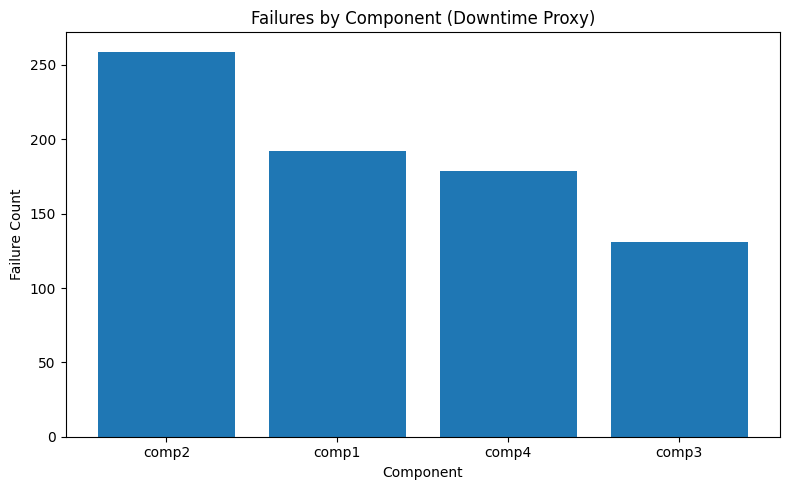

Highest downtime component (proxy): comp2


In [4]:
failure_counts = failures["failure"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(failure_counts.index, failure_counts.values)
plt.title("Failures by Component (Downtime Proxy)")
plt.xlabel("Component")
plt.ylabel("Failure Count")
plt.tight_layout()
plt.savefig("fig1_failures_by_component.png", dpi=200)
plt.show()

print("Highest downtime component (proxy):", failure_counts.idxmax())

DIAGRAM 2: Model Y has elevated failure frequency (failures per machine)

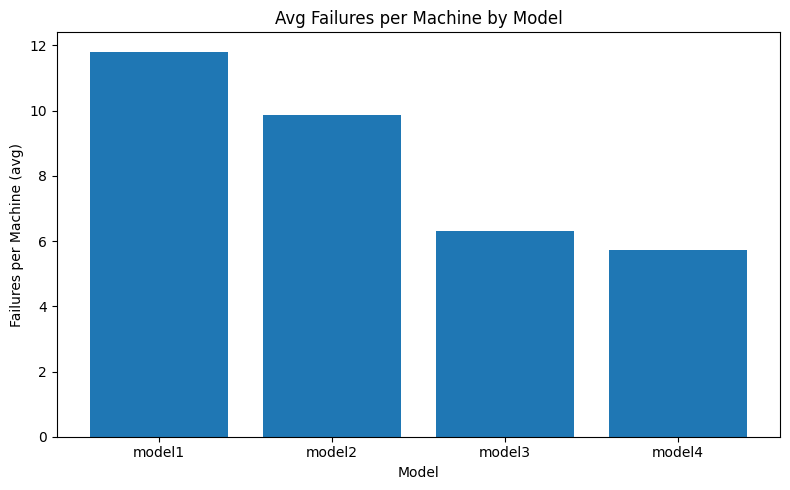

Highest-risk model: model1


In [5]:
# failures per machine
fail_per_machine = failures.groupby("machine_id").size().rename("failure_count")

machines2 = machines.merge(fail_per_machine, on="machine_id", how="left")
machines2["failure_count"] = machines2["failure_count"].fillna(0)

# model-level failure frequency (average failures per machine)
model_summary = machines2.groupby("model")["failure_count"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(model_summary.index.astype(str), model_summary.values)
plt.title("Avg Failures per Machine by Model")
plt.xlabel("Model")
plt.ylabel("Failures per Machine (avg)")
plt.tight_layout()
plt.savefig("fig2_failures_per_machine_by_model.png", dpi=200)
plt.show()

print("Highest-risk model:", model_summary.idxmax())

DIAGRAM 3: Machines older than 12 years show increased risk

We compare:

avg failures per machine for age > 12

vs age ≤ 12

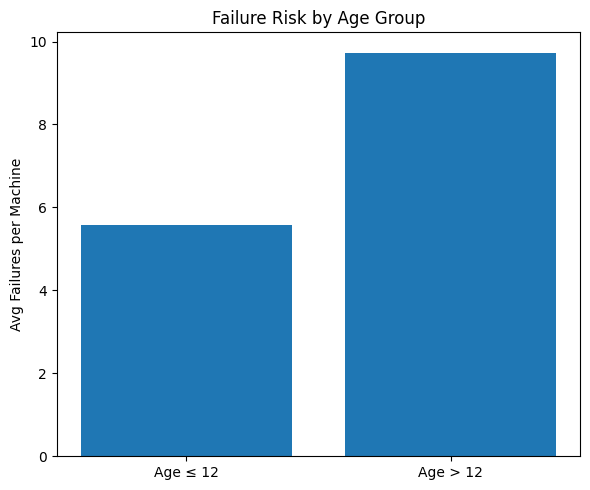

Risk ratio (Age>12 vs Age≤12): 1.7481316470250072


In [6]:
machines2["older_than_12"] = machines2["age"] > 12

age_risk = machines2.groupby("older_than_12")["failure_count"].mean()

plt.figure(figsize=(6,5))
plt.bar(["Age ≤ 12", "Age > 12"], age_risk.values)
plt.title("Failure Risk by Age Group")
plt.ylabel("Avg Failures per Machine")
plt.tight_layout()
plt.savefig("fig3_age_risk_over_12.png", dpi=200)
plt.show()

ratio = age_risk.loc[True] / age_risk.loc[False] if age_risk.loc[False] != 0 else np.nan
print("Risk ratio (Age>12 vs Age≤12):", ratio)

## Q4) Early-Warning Signal: Vibration Patterns Before Failures (Focus: comp4)

**What we test:** whether vibration increases *before* failures, especially **comp4**.

**Definitions (important for correctness):**
- **Baseline vibration:** each machine’s long-run average vibration over the full telemetry history.
- **Pre-failure window:** **t−24 to t−1 hours** (for the bar chart) and **t−48 to t−1 hours** (for the line chart).
- We **exclude t = 0** to avoid mixing “during/after failure” readings into the early-warning signal.

**How to read the plots:**
- Bar chart: average **% change vs baseline** in the 24 hours before failure, by component.
- Line chart: average **% change vs baseline** over the 48 hours leading up to **comp4** failures, with a dashed line at **t = 0** (failure time).


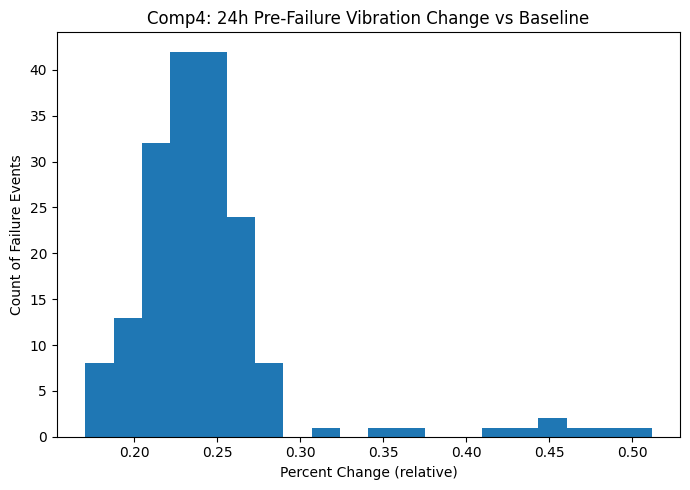

Average pre-failure vibration change (comp4): 0.24421781835627288


In [7]:
# Machine baseline vibration
baseline_vib = telemetry.groupby("machine_id")["vibration"].mean().rename("vib_baseline")

# Only comp4 failures
comp4 = failures[failures["failure"] == "comp4"].copy()

pre_changes = []

telemetry_idx = telemetry.set_index("datetime")

for _, row in comp4.iterrows():
    mid = row["machine_id"]
    t = row["datetime"]

    tdf = telemetry[telemetry["machine_id"] == mid].set_index("datetime").sort_index()

    window = tdf.loc[t - pd.Timedelta(hours=24) : t - pd.Timedelta(hours=1)]

    if len(window) >= 20:  # allow near-complete windows
        vib_mean24 = window["vibration"].mean()
        base = baseline_vib.loc[mid]
        pct_change = (vib_mean24 - base) / base
        pre_changes.append(pct_change)

pre_changes = pd.Series(pre_changes)

plt.figure(figsize=(7,5))
plt.hist(pre_changes.dropna(), bins=20)
plt.title("Comp4: 24h Pre-Failure Vibration Change vs Baseline")
plt.xlabel("Percent Change (relative)")
plt.ylabel("Count of Failure Events")
plt.tight_layout()
plt.savefig("fig4_comp4_prefailure_vibration.png", dpi=200)
plt.show()

print("Average pre-failure vibration change (comp4):", pre_changes.mean())

DIAGRAM 5: Error logs strongly correlate with breakdown probability

Machine-level counts:

total errors

total failures

Then scatter plot + correlation coefficient.

In [20]:
for df in [errors, failures, machines, maint, telemetry]:
    if "machineID" in df.columns:
        df.rename(columns={"machineID": "machine_id"}, inplace=True)

for df in [errors, failures, maint, telemetry]:
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

errors = errors.dropna(subset=["datetime"]).drop_duplicates()
failures = failures.dropna(subset=["datetime"]).drop_duplicates()
maint = maint.dropna(subset=["datetime"]).drop_duplicates()
telemetry = telemetry.dropna(subset=["datetime"]).drop_duplicates()

telemetry = telemetry.sort_values(["machine_id", "datetime"])
failures = failures.sort_values(["machine_id", "datetime"])

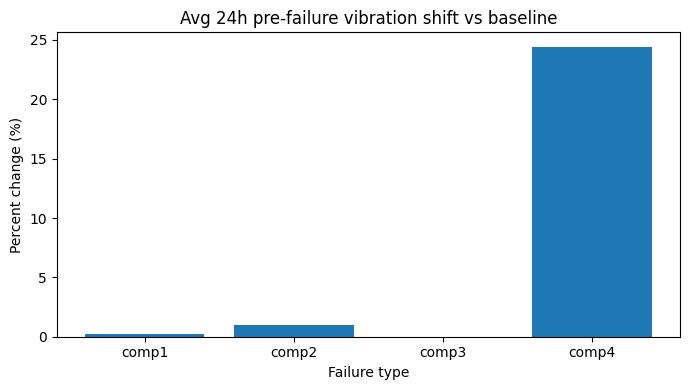

In [21]:
# 1) baseline vibration per machine
baseline_vib = telemetry.groupby("machine_id")["vibration"].mean()

# 2) compute 24h pre-failure vibration percent change for each failure event
rows = []
for _, r in failures.iterrows():
    mid = r["machine_id"]
    t = r["datetime"]
    ftype = r["failure"]

    tdf = telemetry[telemetry["machine_id"] == mid].set_index("datetime").sort_index()
    window = tdf.loc[t - pd.Timedelta(hours=24) : t - pd.Timedelta(hours=1)]

    if len(window) >= 20:  # allow near-complete windows
        vib_pre = window["vibration"].mean()
        vib_base = baseline_vib.loc[mid]
        pct = (vib_pre - vib_base) / vib_base * 100  # percent
        rows.append({"failure": ftype, "vibration_pct": pct})

prefail = pd.DataFrame(rows)

# 3) average by failure type
bar_df = prefail.groupby("failure")["vibration_pct"].mean().reindex(["comp1","comp2","comp3","comp4"])

# 4) plot
plt.figure(figsize=(7,4))
plt.bar(bar_df.index, bar_df.values)
plt.title("Avg 24h pre-failure vibration shift vs baseline (by failure type)")
plt.xlabel("Failure type")
plt.ylabel("Percent change (%)")
plt.tight_layout()
plt.savefig("fig4a_vibration_shift_24h_by_failure.png", dpi=200, bbox_inches="tight")
plt.show()

print("Events used in bar chart:", len(prefail))

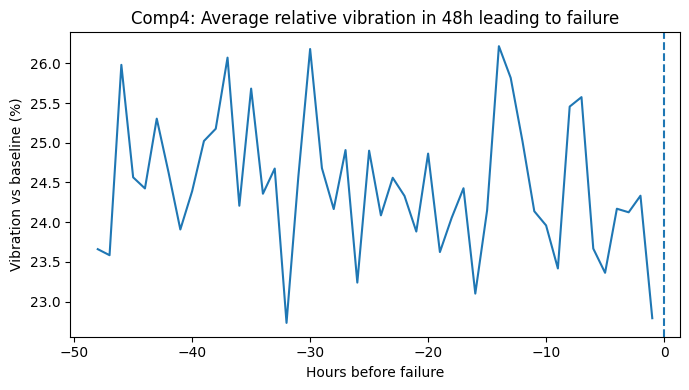

In [22]:
# baseline vibration per machine (reuse)
baseline_vib = telemetry.groupby("machine_id")["vibration"].mean()

# filter only comp4 failures
comp4_fail = failures[failures["failure"] == "comp4"].copy()

# we will collect a list of series, one per event (indexed by hour offset)
series_list = []

for _, r in comp4_fail.iterrows():
    mid = r["machine_id"]
    t = r["datetime"]

    tdf = telemetry[telemetry["machine_id"] == mid].set_index("datetime").sort_index()

    # pull 48 hours leading to failure (exclude hour 0)
    window = tdf.loc[t - pd.Timedelta(hours=48) : t - pd.Timedelta(hours=1)]

    # need full 48 points for clean alignment
    if len(window) == 48:
        base = baseline_vib.loc[mid]

        # percent ABOVE baseline (so you see ~24% level like your screenshot)
        rel = (window["vibration"] - base) / base * 100

        # convert datetime index to hour offsets: -48 ... -1
        rel.index = np.arange(-48, 0)
        series_list.append(rel)

# combine and average
avg_curve = pd.concat(series_list, axis=1).mean(axis=1)

# plot
plt.figure(figsize=(7,4))
plt.plot(avg_curve.index, avg_curve.values)
plt.axvline(0, linestyle="--")  # dashed at failure time
plt.xlim(-48, 0)
plt.xticks([-48, -40, -30, -20, -10, 0])
plt.title("Comp4: Average relative vibration in 48h leading up to failure (t-48 to t-1)")
plt.xlabel("Hours before failure")
plt.ylabel("Vibration vs baseline (%)")
plt.tight_layout()
plt.savefig("fig4b_comp4_vibration_curve_48h.png", dpi=200, bbox_inches="tight")
plt.show()

print("Comp4 failures total:", len(comp4_fail))
print("Comp4 events used in line plot:", len(series_list))

Error Logs and Breakdown Probability

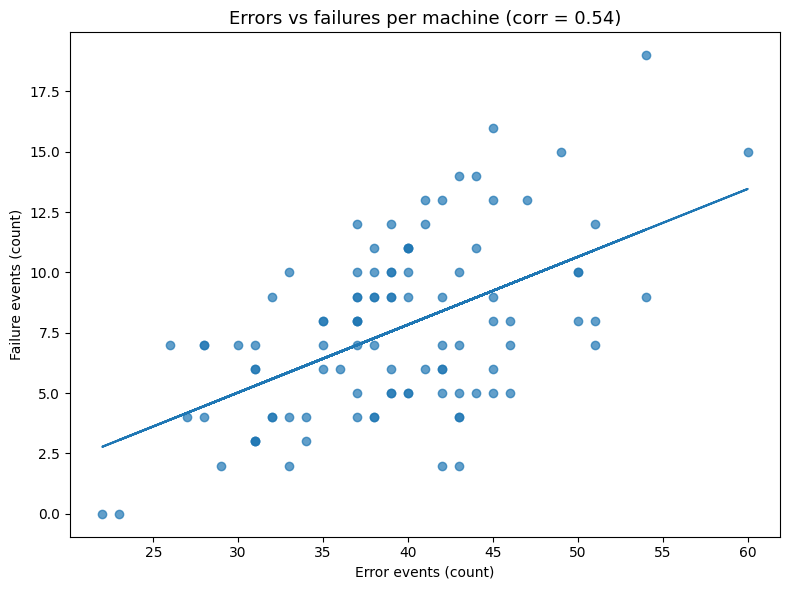

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    corr_df["error_count"],
    corr_df["failure_count"],
    alpha=0.7
)

# Regression line
x = corr_df["error_count"]
y = corr_df["failure_count"]
m, b = np.polyfit(x, y, 1)

plt.plot(x, m*x + b)

plt.title(f"Errors vs failures per machine (corr = {corr:.2f})", fontsize=13)
plt.xlabel("Error events (count)")
plt.ylabel("Failure events (count)")

plt.grid(False)
plt.tight_layout()
plt.show()

DIAGRAM 6: Preventive maintenance timing may need adjustment

6A) Time since last maintenance at failure

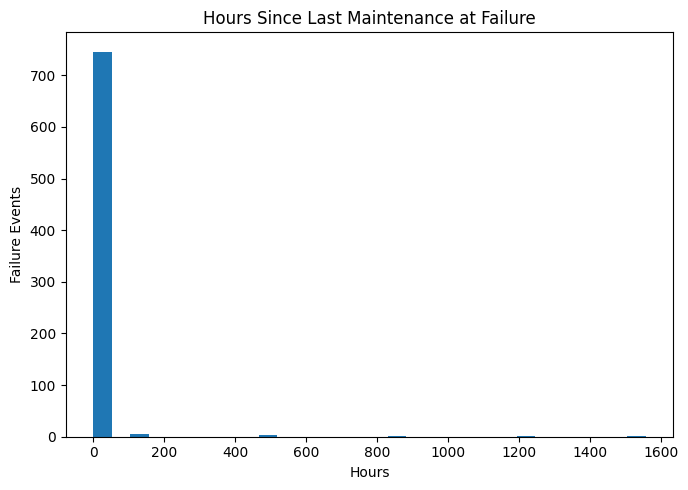

Median hours since last maintenance at failure: 0.0


In [9]:
maint_sorted = maint.sort_values(["machine_id", "datetime"])
fail_sorted = failures.sort_values(["machine_id", "datetime"])

# Pre-build maintenance times per machine
maint_times = {mid: grp["datetime"].values for mid, grp in maint_sorted.groupby("machine_id")}

hours_since = []

for _, row in fail_sorted.iterrows():
    mid = row["machine_id"]
    ft = row["datetime"]

    if mid in maint_times:
        mts = maint_times[mid]
        # last maintenance before failure
        before = mts[mts <= ft.to_datetime64()]
        if len(before) > 0:
            last = before.max()
            hs = (ft.to_datetime64() - last) / np.timedelta64(1, "h")
            hours_since.append(hs)

hours_since = pd.Series(hours_since)

plt.figure(figsize=(7,5))
plt.hist(hours_since.dropna(), bins=30)
plt.title("Hours Since Last Maintenance at Failure")
plt.xlabel("Hours")
plt.ylabel("Failure Events")
plt.tight_layout()
plt.savefig("fig6a_hours_since_last_maint.png", dpi=200)
plt.show()

print("Median hours since last maintenance at failure:", hours_since.median())

6B) Failures happening very close to maintenance timestamps (reactive maintenance signal)

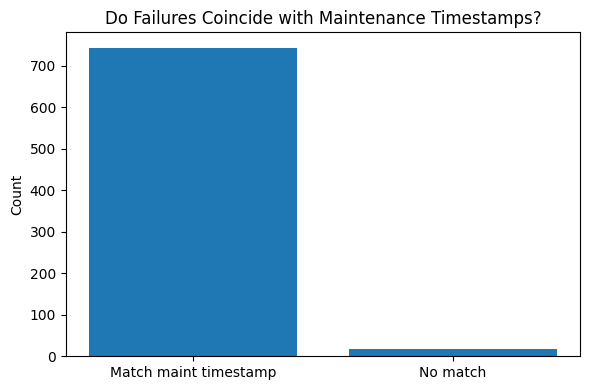

Percent failures that share exact timestamp with maintenance: 97.63%


In [10]:
# Create fast lookup of maintenance timestamps
maint_set = set(zip(maint["machine_id"], maint["datetime"]))

failure_matches = sum((mid, dt) in maint_set for mid, dt in zip(failures["machine_id"], failures["datetime"]))
pct = 100 * failure_matches / len(failures)

plt.figure(figsize=(6,4))
plt.bar(["Match maint timestamp", "No match"], [failure_matches, len(failures)-failure_matches])
plt.title("Do Failures Coincide with Maintenance Timestamps?")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("fig6b_failure_maint_overlap.png", dpi=200)
plt.show()

print(f"Percent failures that share exact timestamp with maintenance: {pct:.2f}%")

Step 7 — Build the PDF using the saved diagrams

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.backends.backend_pdf import PdfPages

In [17]:
import os

figs = [
    "fig1_failures_by_component.png",
    "fig2_failures_per_machine_by_model.png",
    "fig3_age_risk_over_12.png",
    "fig4_comp4_prefailure_vibration.png",
    "fig5_errors_vs_failures.png",
    "fig6a_hours_since_last_maint.png",
    "fig6b_failure_maint_overlap.png"
]

for f in figs:
    print(f, "✅" if os.path.exists(f) else "❌ MISSING")

fig1_failures_by_component.png ✅
fig2_failures_per_machine_by_model.png ✅
fig3_age_risk_over_12.png ✅
fig4_comp4_prefailure_vibration.png ✅
fig5_errors_vs_failures.png ✅
fig6a_hours_since_last_maint.png ✅
fig6b_failure_maint_overlap.png ✅


In [18]:
pdf_name = "Report.pdf"

figs_with_titles = [
    ("1) Highest downtime component (failure mix)", "fig1_failures_by_component.png"),
    ("2) Elevated failure frequency by model", "fig2_failures_per_machine_by_model.png"),
    ("3) Increased risk for machines older than 12 years", "fig3_age_risk_over_12.png"),
    ("4A) 24h pre-failure vibration shift (by failure type)", "fig4a_vibration_shift_24h_by_failure.png"),
    ("4B) Comp4: 48h vibration pattern leading up to failure", "fig4b_comp4_vibration_curve_48h.png"),
    ("5) Errors correlate with breakdown probability", "fig5_errors_vs_failures.png"),
    ("6A) Failure timing vs last maintenance", "fig6a_hours_since_last_maint.png"),
    ("6B) Failures coinciding with maintenance timestamps", "fig6b_failure_maint_overlap.png"),
]

with PdfPages(pdf_name) as pdf:
    for title, fname in figs_with_titles:
        img = mpimg.imread(fname)

        plt.figure(figsize=(8.5, 11))
        plt.axis("off")

        # Title
        plt.text(0.02, 0.97, title,
                 fontsize=14,
                 weight="bold",
                 transform=plt.gca().transAxes)

        # Image
        plt.imshow(img)

        plt.tight_layout()
        pdf.savefig()
        plt.close()

print("✅ Report.pdf created successfully.")

✅ Report.pdf created successfully.
